Mean Squared Error: 106.34
Mean Absolute Error: 8.41
Root Mean Squared Error: 10.31
R2 Score (Model Accuracy): 0.0


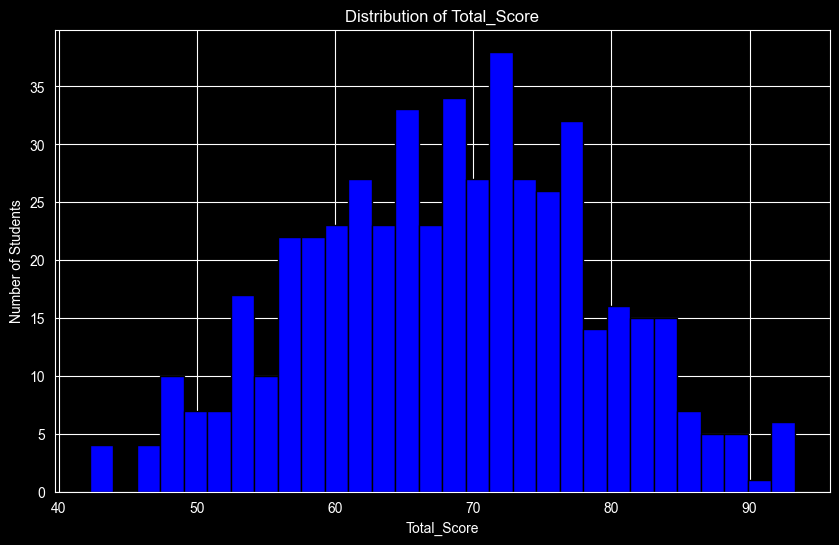

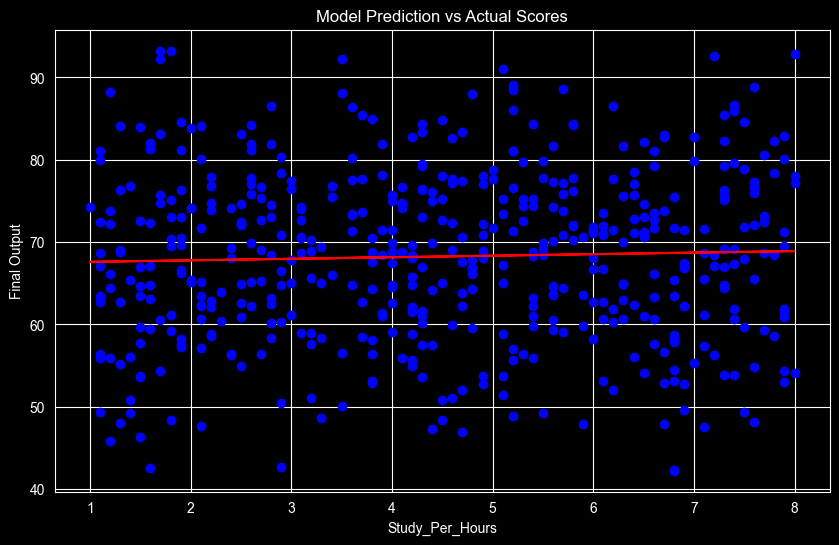

Predicted Score: 9 Hours is [[69.09953675]] Score


C:\Python\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [1]:
import pandas as pd
from matplotlib.pyplot import hist
from seaborn import scatterplot
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#load dataset
data = pd.read_csv("college_students_performance.csv")

#Input & Output
x = data[['Study_Per_Hours']]
y = data[['Total_Score']]

#Train model

model = LinearRegression()
model.fit(x, y)

predicted_scores = model.predict(x)

#Valid regression metrics
#evalute

mse = mean_squared_error(y, predicted_scores)
mae = mean_absolute_error(y, predicted_scores)
rmse = np.sqrt(mse)
r2 = r2_score(y, predicted_scores)

#show results
print("Mean Squared Error:", round(mse,2))
print("Mean Absolute Error:", round(mae,2))
print("Root Mean Squared Error:", round(rmse,2))
print("R2 Score (Model Accuracy):", round(r2,2))

#histogram
plt.figure(figsize=(10,6))
plt,hist(data['Total_Score'],bins=30,color='blue', edgecolor='black')
plt.title('Distribution of Total_Score')
plt.xlabel('Total_Score')
plt.ylabel('Number of Students')
plt.show()


#Scatter + Regression line
plt.figure(figsize=(10,6))
plt.scatter(x,y, color='blue', label='Actual Scores')
plt.plot(x,predicted_scores, color='red', label='Predicted Scores(Regression Line)')
plt.title('Model Prediction vs Actual Scores')
plt.xlabel('Study_Per_Hours')
plt.ylabel('Final Output')
plt.show()

new_hours = 9
predicted_new_scores = model.predict([[new_hours]])
print(f"Predicted Score: {new_hours} Hours is {predicted_new_scores} Score")

In [2]:
# Student success predictor


import pandas as pd

df = pd.read_csv('student_success_dataset.csv')

print("Sample Rows")
print(df.head())

print("DataSet Shape:")
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')

print("Dataset info")
print(df.info())

print("Summary Statistics")
print(df.describe(include='all'))

print("Missing Values")
print(df.isnull().sum())

Sample Rows
   StudyHours  Attendance  PastScore Internet  SleepHours Passed
0           8          62         36       No         5.7     No
1           3          63         48      Yes         7.5     No
2           9          60         89       No         6.4    Yes
3           1          60         46      Yes         7.2     No
4           9          67         92       No         7.7    Yes
DataSet Shape:
Rows: 50, Columns: 6
Dataset info
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   StudyHours  50 non-null     int64  
 1   Attendance  50 non-null     int64  
 2   PastScore   50 non-null     int64  
 3   Internet    50 non-null     str    
 4   SleepHours  50 non-null     float64
 5   Passed      50 non-null     str    
dtypes: float64(1), int64(3), str(2)
memory usage: 2.5 KB
None
Summary Statistics
        StudyHours  Attendance  PastScore Intern

In [3]:
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('student_success_dataset.csv')

print("Missing value in each column")
print(df.isnull().sum())

le = LabelEncoder()

df['Internet'] = le.fit_transform(df['Internet']) #yes = 1, no = 0
df['Passed'] = le.fit_transform(df['Passed'])

print("After Label Encoding")
print(df.head())

print("Data-types after cleaning")
print(df.dtypes)

Missing value in each column
StudyHours    0
Attendance    0
PastScore     0
Internet      0
SleepHours    0
Passed        0
dtype: int64
After Label Encoding
   StudyHours  Attendance  PastScore  Internet  SleepHours  Passed
0           8          62         36         0         5.7       0
1           3          63         48         1         7.5       0
2           9          60         89         0         6.4       1
3           1          60         46         1         7.2       0
4           9          67         92         0         7.7       1
Data-types after cleaning
StudyHours      int64
Attendance      int64
PastScore       int64
Internet        int64
SleepHours    float64
Passed          int64
dtype: object


Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         7

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



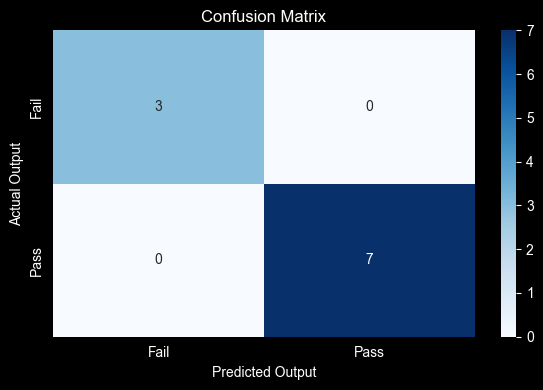

-------------Predict Your Results-------------
Prediction Based on input: Pass


C:\Python\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('student_success_dataset.csv')

le = LabelEncoder()
data['Internet'] = le.fit_transform(data['Internet'])
data['Passed'] = le.fit_transform(data['Passed'])

features = ['StudyHours','Attendance','PastScore','SleepHours']
scaler = StandardScaler()

df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df_scaled[features])

x = df_scaled[features]#feature
y = df_scaled['Passed']#target
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

model = LogisticRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Classification Report")
print(classification_report(y_test, y_pred))

confusion_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["Fail","Pass"], yticklabels=["Fail","Pass"])
plt.xlabel('Predicted Output')
plt.ylabel('Actual Output')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print("-------------Predict Your Results-------------")
try:
    study_hours = float(input("Please enter your study hours: "))
    attendance = float(input("Please enter your attendance: "))
    past_score = float(input("Please enter your past score: "))
    sleep_score = float(input("Please enter your sleep hours: "))

    user_input_df = pd.DataFrame([{
        'StudyHours': study_hours,
        'Attendance': attendance,
        'PastScore': past_score,
        'SleepHours': sleep_score
    }])

    user_input_scaled = scaler.fit_transform(user_input_df)

    prediction = model.predict(user_input_scaled)[0]

    result = "Pass" if prediction == 1 else "Fail"
    print(f"Prediction Based on input: {result}")
except Exception as e:
    print(f"An error occured: {e}")



